# 04 — QI: Production Indices

QI normalizes production to a base period (2014–2016 = 100), so it's the cleanest
way to compare **trends** across countries of very different sizes. Also has
per-capita indices — directly relevant to food security framing.

Questions:
- Which regions have rising vs falling per-capita production? (food-security signal)
- Does the index confirm the raw-QCL story, or diverge (base-period / composition effects)?

In [1]:
import sys
from pathlib import Path
sys.path.append(str(Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()))

import pandas as pd
import matplotlib.pyplot as plt

from src.load import load_dataset, load_codes
from src.clean import standardize_columns, split_aggregates, resolve_china, data_quality_report
from src.viz import trend_top_bottom, save

## 1. Load QI and inspect elements — pick gross PIN and per-capita PIN

In [2]:
qi_full = standardize_columns(load_dataset("QI"))
print(qi_full[["element_code", "element", "unit"]].drop_duplicates().to_string(index=False))

[cache] QI_long.parquet


 element_code                                                    element  unit
          432            Gross Production Index Number (2014-2016 = 100)   NaN
          434 Gross per capita Production Index Number (2014-2016 = 100)   NaN


## 2. Inspect items, then filter to a broad food aggregate
Item like "Agriculture" or "Crops" (verify exact name below). Keep the
Gross PIN and per-capita PIN elements.

In [3]:
print(qi_full[["item_code", "item"]].drop_duplicates().head(30).to_string(index=False))

 item_code                                                                     item
       515                                                                   Apples
       526                                                                 Apricots
        44                                                                   Barley
       568                                             Cantaloupes and other melons
       569                                                                     Figs
      1163                                      Game meat, fresh, chilled or frozen
       560                                                                   Grapes
      1062                                                 Hen eggs in shell, fresh
       333                                                                  Linseed
        56                                                             Maize (corn)
      1137                            Meat of camels, fresh or chilled (indi

In [4]:
# Adjust these to the exact strings shown above:
QI_ITEMS = ["Agriculture"]
QI_ELEMENTS = qi_full[qi_full["element"].str.contains("capita|Gross Production Index", case=False, na=False)]["element"].unique().tolist()
print("matched elements:", QI_ELEMENTS)

qi = qi_full[qi_full["item"].isin(QI_ITEMS) & qi_full["element"].isin(QI_ELEMENTS)].copy()
qi.head()

matched elements: ['Gross Production Index Number (2014-2016 = 100)', 'Gross per capita Production Index Number (2014-2016 = 100)']


,area_code,area_code_(m49),area,item_code,item_code_(cpc),item,element_code,element,unit,year,value,flag
88,2,'004,Afghanistan,2051,'F2051,Agriculture,432,Gross Production Index Number (2014-2016 = 100),NaN,1961,42.59,E
89,2,'004,Afghanistan,2051,'F2051,Agriculture,434,Gross per capita Production Index Number (2014...,NaN,1961,156.03,E
194,3,'008,Albania,2051,'F2051,Agriculture,432,Gross Production Index Number (2014-2016 = 100),NaN,1961,22.63,E
195,3,'008,Albania,2051,'F2051,Agriculture,434,Gross per capita Production Index Number (2014...,NaN,1961,38.63,E
324,4,'012,Algeria,2051,'F2051,Agriculture,432,Gross Production Index Number (2014-2016 = 100),NaN,1961,21.97,E


## 3. Quality + coverage

In [5]:
for k, v in data_quality_report(qi).items():
    print(f"{k}: {v}")

rows: 27540
n_missing_value: 0
pct_missing_value: 0.0
flag_distribution: {'E': 1.0}
year_min: 1961
year_max: 2024


In [9]:
countries, aggregates = split_aggregates(qi)
countries = resolve_china(countries)

## 4. Regional trends from the aggregates table
The aggregates frame contains World / continents / income groups — perfect for a
clean regional-shift picture without summing countries yourself.

figure -> /mnt/d/Sweta/Northeastern/Codes/python/wid-datathon-grow-eda/outputs/figures/qi_percapita_by_region.png


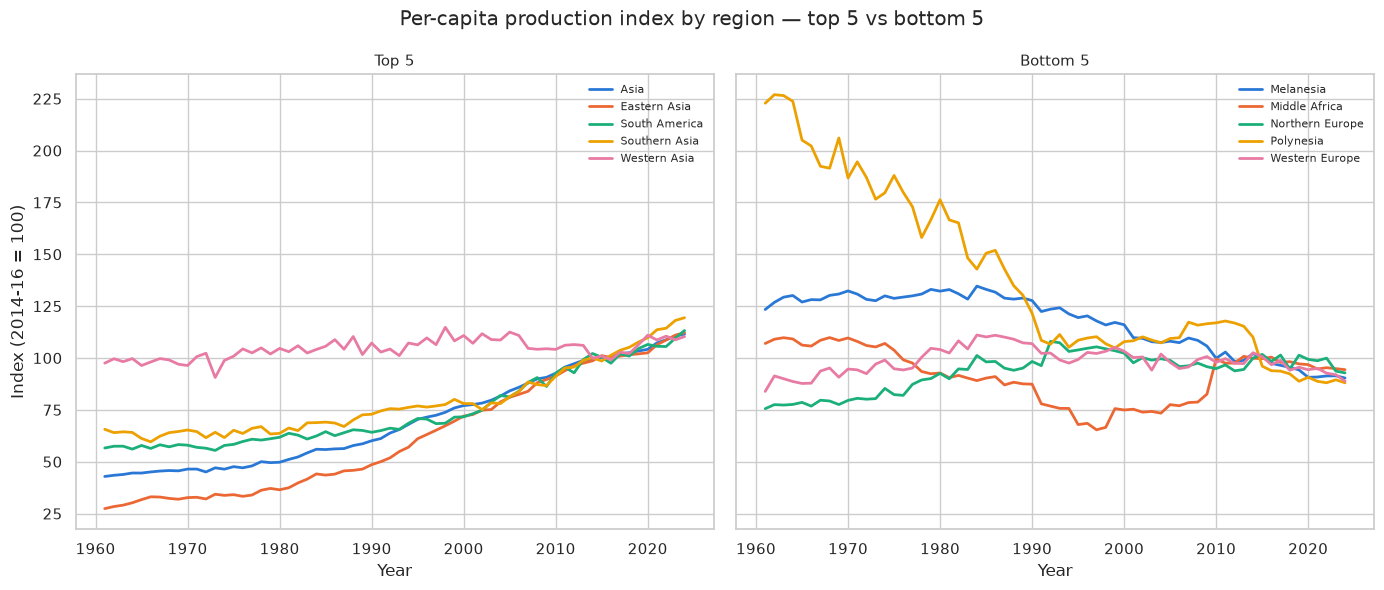

In [7]:
per_capita = aggregates[aggregates["element"].str.contains("capita", case=False, na=False)]
fig, axes = trend_top_bottom(per_capita, "year", "value", group_col="area", n=5,
                             title="Per-capita production index by region — top 5 vs bottom 5",
                             ylabel="Index (2014-16 = 100)")
save(fig, "qi_percapita_by_region")
plt.show()

## 5. Rising vs falling countries (latest year vs a decade ago)

In [8]:
def change_vs_decade(frame, element_kw="capita"):
    sub = frame[frame["element"].str.contains(element_kw, case=False, na=False)]
    latest = int(sub["year"].max())
    a = sub[sub["year"] == latest].set_index("area")["value"]
    b = sub[sub["year"] == latest - 10].set_index("area")["value"]
    change = (a - b).dropna().sort_values()
    return change, latest

change, latest = change_vs_decade(countries)
print(f"Biggest 10-year DROPS in per-capita production index (as of {latest}):")
print(change.head(15))
print("\nBiggest RISES:")
print(change.tail(15))

Biggest 10-year DROPS in per-capita production index (as of 2024):
area
Cuba                  -47.65
Samoa                 -47.54
Malta                 -44.75
Iraq                  -41.72
Suriname              -35.84
Somalia               -34.20
Grenada               -30.97
Cabo Verde            -30.07
Zambia                -29.79
Haiti                 -29.70
Gambia                -28.42
Solomon Islands       -26.92
Trinidad and Tobago   -26.58
Saint Lucia           -23.82
Belize                -22.85
Name: value, dtype: float64

Biggest RISES:
area
Azerbaijan                  29.20
Tuvalu                      32.22
Qatar                       32.61
Portugal                    33.27
Singapore                   39.41
Central African Republic    39.54
Fiji                        40.69
Tajikistan                  44.51
Bosnia and Herzegovina      45.70
Oman                        47.80
Guinea                      47.98
Saudi Arabia                52.73
Senegal                     58.79
Do

**Checkpoint:** QI is low-effort, high-signal for a food-security angle. Note whether
it tells the same story as QCL or reveals something QCL's raw tonnage hides.